In [1]:
!pip install -q medmnist faiss-cpu transformers torchvision accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.1 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import faiss
import matplotlib.pyplot as plt

from medmnist import PneumoniaMNIST
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [3]:
test_dataset = PneumoniaMNIST(split="test", download=True)

print("Test set size:", len(test_dataset))

100%|██████████| 4.17M/4.17M [00:00<00:00, 29.9MB/s]

Test set size: 624


In [8]:
model_name = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

model.eval()

print("CLIP model loaded successfully.")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded successfully.


In [13]:
image_embeddings = []
labels = []

model.eval()

with torch.no_grad():
    for img, label in tqdm(test_dataset):

        # Ensure RGB format
        if isinstance(img, Image.Image):
            img_rgb = img.convert("RGB")
        else:
            img_rgb = Image.fromarray(img.squeeze()).convert("RGB")

        inputs = processor(images=img_rgb, return_tensors="pt").to(device)

        # Directly use vision encoder
        vision_outputs = model.vision_model(pixel_values=inputs["pixel_values"])

        pooled_output = vision_outputs.pooler_output  # (batch_size, hidden_dim)

        # Project to CLIP embedding space
        image_features = model.visual_projection(pooled_output)

        # Normalize for cosine similarity
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        image_embeddings.append(image_features.cpu().numpy()[0])
        labels.append(int(label[0]))

image_embeddings = np.array(image_embeddings).astype("float32")
labels = np.array(labels)

print("Embeddings shape:", image_embeddings.shape)

100%|██████████| 624/624 [00:07<00:00, 87.69it/s] 

Embeddings shape: (624, 512)


In [14]:
dimension = image_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)
index.add(image_embeddings)

print("FAISS index size:", index.ntotal)

FAISS index size: 624


In [15]:
faiss.write_index(index, "pneumonia_clip.index")
np.save("pneumonia_clip_embeddings.npy", image_embeddings)
np.save("pneumonia_clip_labels.npy", labels)

print("Index and embeddings saved successfully.")

Index and embeddings saved successfully.


In [16]:
def image_to_image_search(query_index, k=5):

    query_vector = image_embeddings[query_index].reshape(1, -1)

    similarities, indices = index.search(query_vector, k + 1)

    # Remove self-match (first result)
    return indices[0][1:], similarities[0][1:]

In [19]:
def visualize_retrieval(query_idx, retrieved_indices):

    fig, axes = plt.subplots(1, len(retrieved_indices) + 1, figsize=(15, 3))

    # --- Query image ---
    q_img, q_label = test_dataset[query_idx]

    if isinstance(q_img, Image.Image):
        axes[0].imshow(q_img, cmap="gray")
    else:
        axes[0].imshow(q_img.squeeze(), cmap="gray")

    axes[0].set_title(f"Query\nLabel={q_label[0]}")
    axes[0].axis("off")

    # --- Retrieved images ---
    for i, idx in enumerate(retrieved_indices):
        img, label = test_dataset[idx]

        if isinstance(img, Image.Image):
            axes[i+1].imshow(img, cmap="gray")
        else:
            axes[i+1].imshow(img.squeeze(), cmap="gray")

        axes[i+1].set_title(f"Label={label[0]}")
        axes[i+1].axis("off")

    plt.tight_layout()
    plt.show()

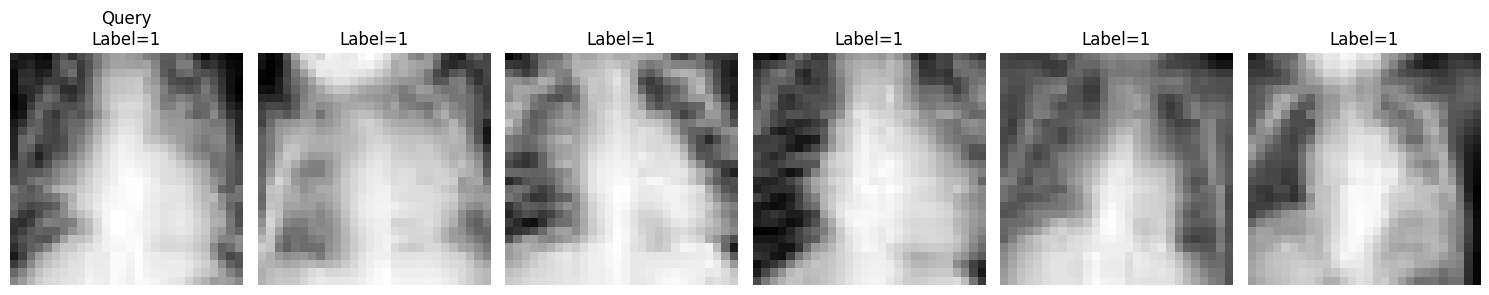

In [20]:
query_id = 10
retrieved_ids, scores = image_to_image_search(query_id, k=5)
visualize_retrieval(query_id, retrieved_ids)

In [21]:
def text_to_image_search(text_query, k=5):

    with torch.no_grad():
        inputs = processor(text=[text_query], return_tensors="pt", padding=True).to(device)

        # Use text encoder directly
        text_outputs = model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        pooled_output = text_outputs.pooler_output

        text_features = model.text_projection(pooled_output)

        # Normalize for cosine similarity
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        text_vector = text_features.cpu().numpy().astype("float32")

        similarities, indices = index.search(text_vector, k)

    return indices[0], similarities[0]

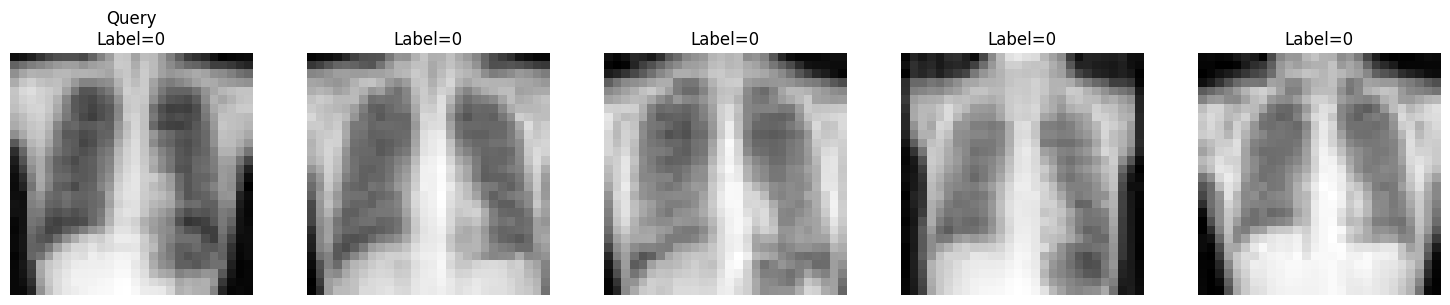

In [22]:
query_text = "Chest X-ray showing pneumonia with lung opacities"

retrieved_ids, scores = text_to_image_search(query_text, k=5)

# Show first result as query visualization reference
visualize_retrieval(retrieved_ids[0], retrieved_ids[1:])

In [23]:
text_to_image_search("Normal chest X-ray", k=5)

(array([106, 623, 614, 292,  25]),
 array([0.30281484, 0.30170113, 0.2990126 , 0.2982229 , 0.2965176 ],
       dtype=float32))

In [24]:
def precision_at_k(k=5):

    total_precision = 0

    for i in range(len(test_dataset)):
        retrieved_ids, _ = image_to_image_search(i, k)
        correct = sum(labels[r] == labels[i] for r in retrieved_ids)
        total_precision += correct / k

    return total_precision / len(test_dataset)

In [25]:
for k in [1, 3, 5]:
    p = precision_at_k(k)
    print(f"Precision@{k}: {p:.4f}")

Precision@1: 0.8045
Precision@3: 0.7943
Precision@5: 0.7833


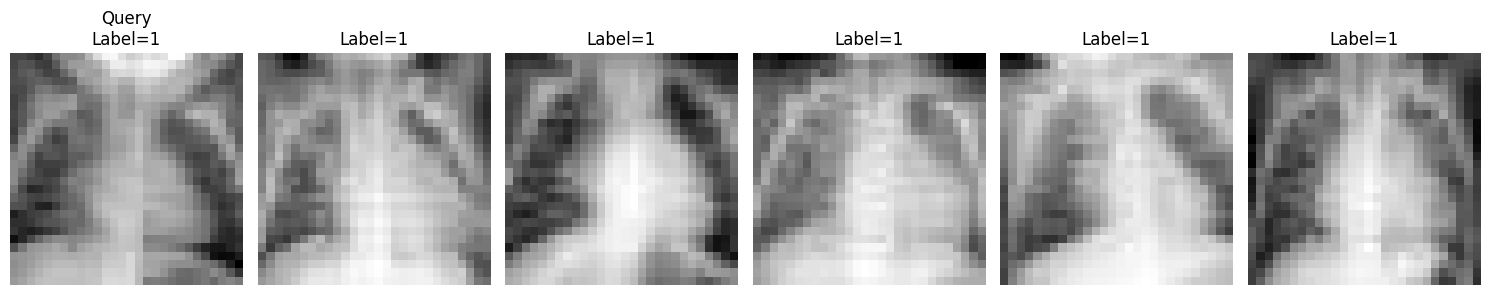

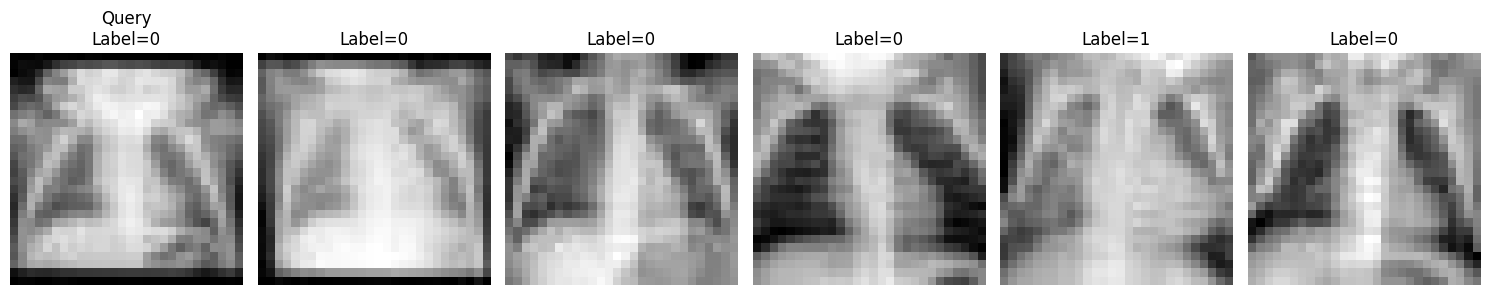

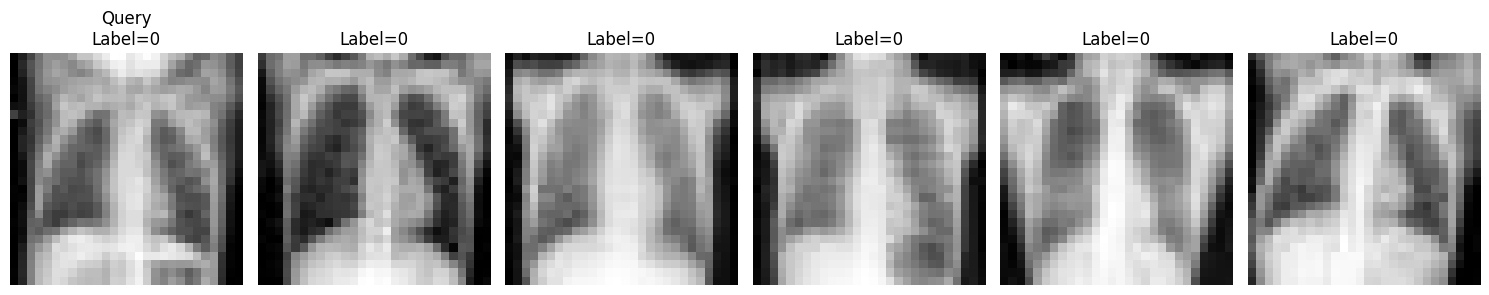

In [26]:
import random

for _ in range(3):
    q = random.randint(0, len(test_dataset)-1)
    retrieved_ids, _ = image_to_image_search(q, k=5)
    visualize_retrieval(q, retrieved_ids)